In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Comprendre les préférences des clients et les tendances des restaurants est essentiel pour prendre des décisions commerciales éclairées dans l’industrie alimentaire. Dans cet article, nous analyserons le jeu de données de restaurants de Zomato en utilisant Python pour trouver des informations pertinentes. Nous visons à répondre à des questions telles que :

Est-ce que plus de restaurants proposent la livraison en ligne par rapport aux services en ligne ?
Quels types de restaurants sont les plus appréciés du grand public ?
Quelle gamme de prix les couples préfèrent-ils pour sortir manger ?

In [4]:
dataframe = pd.read_csv("data/zomato.csv")
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


# ETAPE 1 : NETTPYAGE ET PREPARATION DE DONNEES

In [6]:
def handleRate(value):
    value=str(value).split('/')
    value=value[0];
    return float(value)

dataframe['rate'] = dataframe['rate'].apply(handleRate)
dataframe.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [7]:
dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    str    
 1   online_order                 148 non-null    str    
 2   book_table                   148 non-null    str    
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    str    
dtypes: float64(1), int64(2), str(4)
memory usage: 12.0 KB


In [8]:
dataframe.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

Text(0.5, 0, 'type of restaurant')

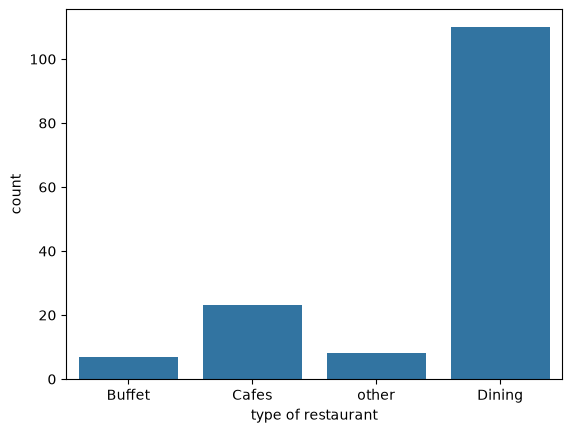

In [11]:
# identifiant les catageories de restaurantes populaire
sns.countplot(x=dataframe['listed_in(type)'])
plt.xlabel("type of restaurant")

Text(0, 0.5, 'votes')

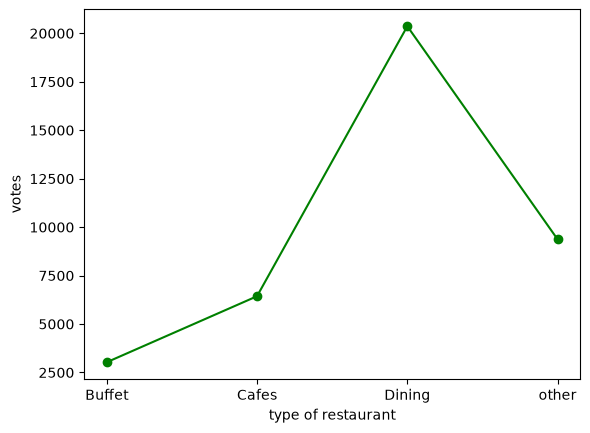

In [14]:
grounped_data = dataframe.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': grounped_data})
plt.plot(result, c='green', marker='o')
plt.xlabel('type of restaurant')
plt.ylabel('votes')

In [15]:
max_votes = dataframe['votes'].max()
restaurant_with_votes = dataframe.loc[dataframe['votes'] == max_votes,'name']
print("restaurant(s) with the maximum votes:")
restaurant_with_votes

restaurant(s) with the maximum votes:


38    Empire Restaurant
Name: name, dtype: str

<Axes: xlabel='online_order', ylabel='count'>

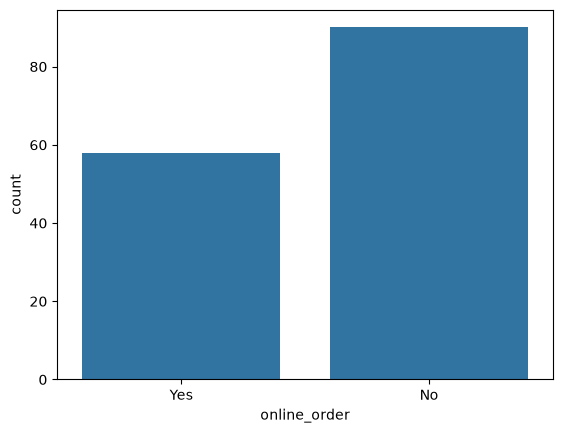

In [16]:
# disponibilité de commandes en lignes
sns.countplot(x=dataframe['online_order'])

Text(0.5, 1.0, 'ratings distribution')

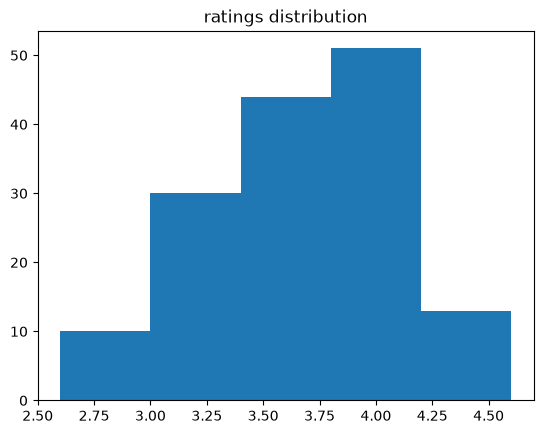

In [17]:
#verification de la repartition des notes à partir de la colonne des tax
plt.hist(dataframe['rate'], bins=5)
plt.title('ratings distribution')

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

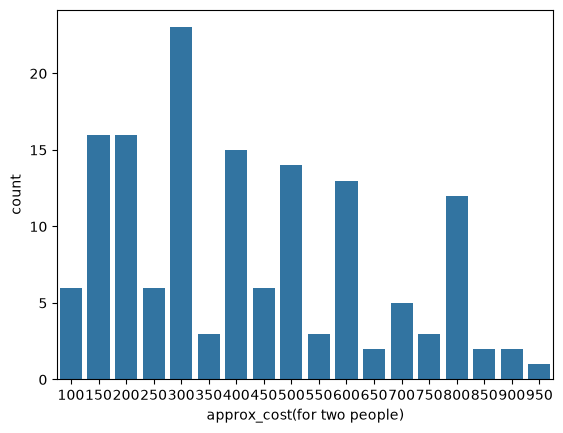

In [18]:
couple_data = dataframe['approx_cost(for two people)']
sns.countplot(x=couple_data)

#La majorité des couples préfèrent des restaurants à un coût approximatif de 300 roupies

<Axes: xlabel='online_order', ylabel='rate'>

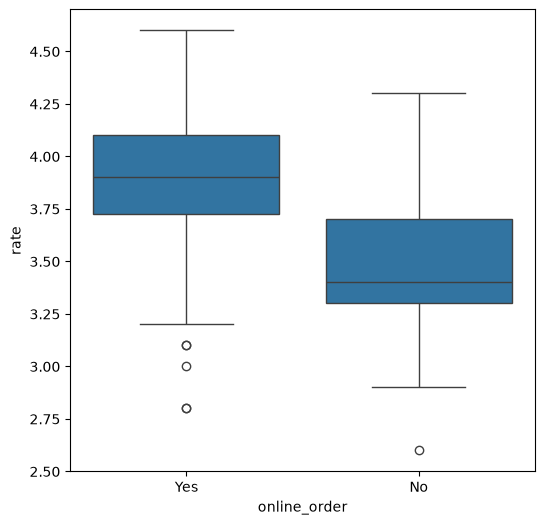

In [19]:
plt.figure(figsize=(6,6))
sns.boxplot(x='online_order', y='rate', data = dataframe)

Les commandes en ligne ont reçu des notes inférieures comparées aux commandes en ligne qui ont obtenu d’excellentes évaluations.

Text(50.38563368055554, 0.5, 'listed in (type)')

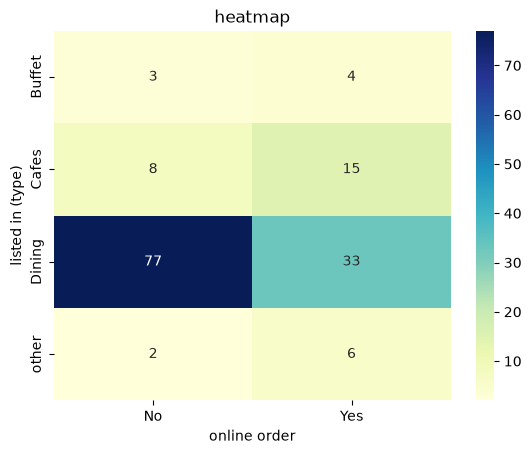

In [21]:
pivot_table = dataframe.pivot_table(index='listed_in(type)',
                                    columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('heatmap')
plt.xlabel('online order')
plt.ylabel('listed in (type)')


On peut dire que les restaurants restaurants acceptent principalement les commandes en ligne tandis que les cafés reçoivent principalement des commandes en ligne. Cela suggère que les clients préfèrent passer commande en personne dans les restaurants mais préfèrent commander en ligne dans des cafés.